<a href="https://colab.research.google.com/github/kartikeyabekkari/HyperRealisticNisqSimulation/blob/main/Hyper_Realistic_NISQ_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup & Imports



In [3]:
!pip install --upgrade --force-reinstall cirq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.7/733.7 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.5/176.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import warnings
warnings.filterwarnings("ignore")


try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")

import math
import matplotlib.pyplot as plt
import cirq_web
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
deg = np.radians

print("Libraries Imported Successfully!")

Libraries Imported Successfully!




---


#Parameters





In [2]:
import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
deg = np.radians

---
#Divider
---

In [11]:
#================= Parameters =================
base_noise = 0.00001

single_qubit_noise = 0.00036
single_qubit_plus_minus = 0.00013

multi_qubit_noise = 0.0014
multi_qubit_plus_minus = 0.00052

readout_noise = 0.0067
readout_noise_plus_minus = 0.0051

amplitude_damp_chance = 0.00092647
#---------------------------------
coupling_stength = 20 #-- In Mega-Hertz
gate_action_time = 42 #-- In nanoseconds
frequency_overlap = 10 #-- In Mega-Hertz
distance_between_qubits = 1 #-- Needs to be the same unit as decay length
decay_length = 1 #-- has to have the same units as the distance between qubits
#---------------------------------
number_of_qubits_in_the_circuit = 3

number_of_runs = 10000
#================= Build Circuit =================
qubits = cirq.LineQubit.range(number_of_qubits_in_the_circuit)
base_circuit = cirq.Circuit([

#-------------------------------------------------
cirq.H(qubits[0]),
cirq.CNOT(qubits[0],qubits[1]),
cirq.CNOT(qubits[0],qubits[2]),
cirq.measure(qubits, key='result'),
#------------------ Edit Here ^ ------------------

])

print(f"Your Circuit:\n\n{base_circuit}\n")

Your Circuit:

0: ───H───@───@───M('result')───
          │   │   │
1: ───────X───┼───M─────────────
              │   │
2: ───────────X───M─────────────



---
#Functions
---

In [15]:
from cirq.ops.parity_gates import YYPowGate

SINGLE_GATE_TYPES = (
      cirq.XPowGate,
      cirq.YPowGate,
      cirq.ZPowGate,
      cirq.HPowGate,
  )
  # Define multi gate types
MULTI_GATE_TYPES = (
      cirq.CXPowGate,
      cirq.CYPowGate,
      cirq.CZPowGate,
      cirq.XXPowGate,
      cirq.YYPowGate,
      cirq.ZZPowGate,
      cirq.CCNotPowGate,
      cirq.CCXPowGate,
      cirq.CCYPowGate,
      cirq.CCZPowGate,
      cirq.ISwapPowGate,
      cirq.SwapPowGate,
  )


def initialize():
  global t, g, f, d0, measured_qubits, readout_error_nums, multi_gate_error_nums, single_gate_error_nums

  t = gate_action_time * (10**(-1*9)) #-- convert from nanoseconds to seconds
  g = coupling_stength * (10**6) #-- convert from MHz to Hz
  f = frequency_overlap * (10**6) #-- convert from Mhz to Hz
  d0 = decay_length # abriviate for equation later


  # Defines which qubits are being measured
  measured_qubits = [
          q for op in base_circuit.all_operations() if isinstance(op.gate, cirq.MeasurementGate) and op.gate.key == 'result' for q in op.qubits
      ]

  #---------- error values for each type of gate ----------
  readout_error_nums = [(max(0,readout_noise-readout_noise_plus_minus)),readout_noise,(min(1,readout_noise+readout_noise_plus_minus))]
  multi_gate_error_nums = [(max(0, multi_qubit_noise-multi_qubit_plus_minus)),multi_qubit_noise,(min(1,multi_qubit_noise+multi_qubit_plus_minus))] # Ensured the lower bound is not negative
  single_gate_error_nums = [(max(0,single_qubit_noise-single_qubit_plus_minus)),single_qubit_noise,(min(1,single_qubit_noise+single_qubit_plus_minus))]

def build_shot_circuit(original_circuit, all_qubits):
    circuit = cirq.Circuit()

    num_moments = len(original_circuit)

    for moment in original_circuit:
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
                circuit.append(cirq.measure(all_qubits)) #-- Collapses superposition (acts as the physical measurement of the circuit)
                circuit.append(cirq.bit_flip(random.choice(readout_error_nums)).on_each(all_qubits)) #-- assigns a chance that the measurement had an error, where they read the state of the qubit wrong (preps for the final graphed measurment)
                circuit.append(moment) #-- puts back the final measurment
                continue
        circuit.append(moment)
        single_loud_qubits = {
            q for op in moment if isinstance(op.gate, SINGLE_GATE_TYPES) for q in op.qubits}
        multi_loud_qubits = {
            q for op in moment if isinstance(op.gate, MULTI_GATE_TYPES) for q in op.qubits}

        bit_flip_ops = []
        phase_flip_ops = []
        depolarize_ops = []
        flipped_qubit_indices = []

        for q_idx, q in enumerate(all_qubits):
            if q in multi_loud_qubits:
              error_rate = random.choice(multi_gate_error_nums)
            elif q in single_loud_qubits:
              error_rate = random.choice(single_gate_error_nums)
            else:
              error_rate = base_noise

            if q not in multi_loud_qubits:
              bit_flip_ops.append(cirq.bit_flip(p=error_rate)(q))

            phase_flip_ops.append(cirq.phase_flip(p=error_rate)(q))
            depolarize_ops.append(cirq.depolarize(p=error_rate)(q))

            if np.random.rand() < error_rate:
                flipped_qubit_indices.append(q_idx)

        circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(phase_flip_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(amplitude_damp_chance)(q) for q in all_qubits))
        circuit.append(cirq.Moment(cirq.phase_damp(amplitude_damp_chance)(q) for q in all_qubits))

        # --- Crosstalk made with the flip idx above ---

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
          if any(isinstance(op.gate, MULTI_GATE_TYPES) for op in moment): #-- comment this line out if the computer your modeling doesnt use tunable frequencies to block out crosstalk
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0  # this qubit already flipped, therefore treat as certain
            elif flipped_qubit_indices:
                distance = [
                    abs(q_idx - flipped_idx) for flipped_idx in flipped_qubit_indices]
                shortest_distance = min(distance)



                crosstalk_p = (

                    ((g**2*math.e**((-2*shortest_distance*distance_between_qubits)/d0))/(g**2*math.e**((-2*shortest_distance*distance_between_qubits)/d0)+(f**2)/4))*math.sin(t*math.sqrt((g**2*math.e**((-2*shortest_distance*distance_between_qubits)/d0))+(f**2)/4))**2
                )



            else:
              # no flip happend in the whole moment, no opportunity for crosstalk
                crosstalk_p = 0.0

            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))



    return circuit
# ================= Simulate + collect results =================
total_counts = Counter()


def simulate(circuit, type_of_noise=None):
    #Runs circuit once (1 shot) and adds the result into total_counts
    sim = cirq.Simulator()
    result = sim.run(circuit)
    total_counts.update(result.histogram(key='result'))


def graph(num_qubits, num_runs):
    # Creates bar chart
    print("\n--- SIMULATION RESULTS ---\n")

    total_possible_states = 2 ** num_qubits
    labels, values = [], []
    for outcome in range(total_possible_states):
        binary_string = format(outcome, f"0{num_qubits}b")
        labels.append(binary_string)
        actual_count = total_counts.get(outcome, 0)
        values.append(actual_count)
        print(f"State |{binary_string}⟩: {actual_count} times ~ {(actual_count / num_runs) * 100:.2f}%")

    plt.figure(figsize=(1 + 2 * num_qubits, 6))
    plt.bar(labels, values, color="lightblue", edgecolor="lightblue")
    plt.title(f"Total For {num_runs} Runs")
    plt.xlabel("Quantum States")
    plt.ylabel("Total Count")
    plt.xticks(rotation=315, fontsize=8)
    plt.grid(axis="y", linestyle="--", alpha=0.85)
    plt.tight_layout()
    plt.show()


def run_NISQ_simulation(circuit_template, all_qubits, num_runs):
    initialize()
    #-------------------------- Parameters ^--------------------------

    # defines how to run

    total_counts.clear()
    print(f'Circuit:\n{base_circuit}')
    for _ in range(num_runs):
        shot_circuit = build_shot_circuit(circuit_template, all_qubits)
        #if _ == num_runs-1 :
           #print(f'{shot_circuit}\n\n\n')
        simulate(shot_circuit)
    graph(len(measured_qubits), num_runs)

---
# Run the circuit
---


--- SIMULATION RESULTS ---

State |000⟩: 5035 times ~ 50.35%
State |001⟩: 14 times ~ 0.14%
State |010⟩: 16 times ~ 0.16%
State |011⟩: 4 times ~ 0.04%
State |100⟩: 6 times ~ 0.06%
State |101⟩: 16 times ~ 0.16%
State |110⟩: 20 times ~ 0.20%
State |111⟩: 4889 times ~ 48.89%


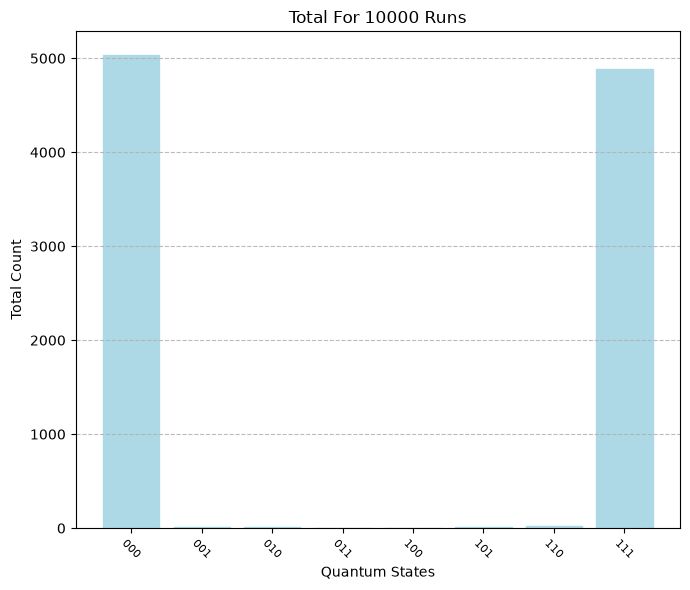

In [16]:
sim = cirq.Simulator(noise=cirq.depolarize(p=0.0014))
total_counts = Counter()
for _ in range(10000):
  result = sim.run(base_circuit)
  total_counts.update(result.histogram(key='result'))
graph(len(measured_qubits),10000)

Circuit:
0: ───H───@───@───M('result')───
          │   │   │
1: ───────X───┼───M─────────────
              │   │
2: ───────────X───M─────────────

--- SIMULATION RESULTS ---

State |000⟩: 4909 times ~ 49.09%
State |001⟩: 56 times ~ 0.56%
State |010⟩: 63 times ~ 0.63%
State |011⟩: 54 times ~ 0.54%
State |100⟩: 42 times ~ 0.42%
State |101⟩: 65 times ~ 0.65%
State |110⟩: 49 times ~ 0.49%
State |111⟩: 4762 times ~ 47.62%


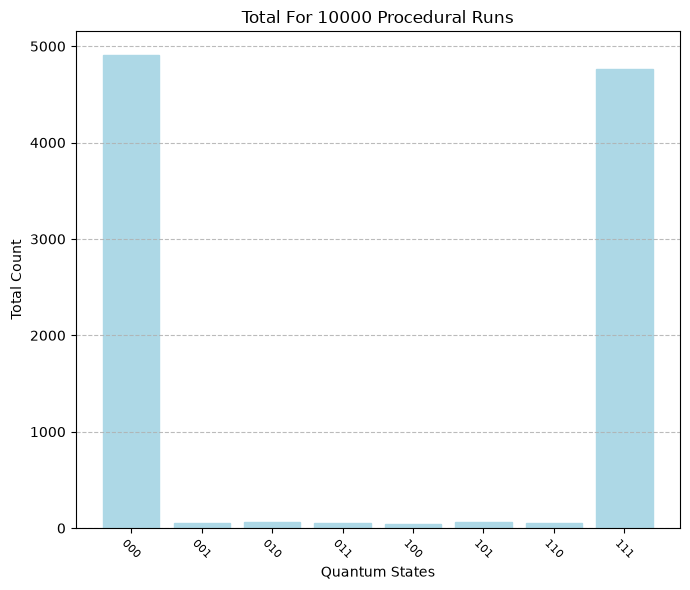

In [14]:
run_NISQ_simulation(base_circuit, qubits, number_of_runs)

#
---

---
# Generate Grovers algorithm
---

In [5]:
import math
number_choices = 8
correct_choice = 2

"Get qubits to use in the circuit for Grover's algorithm."
nqubits = 3

def generate_binary_strings(number_choices):
    n = int(math.log(number_choices,2))
    binary_strings = []
    for i in range(2**n):
        binary_string = bin(i)[2:].zfill(n)
        binary_strings.append(binary_string)
    return binary_strings

ls = generate_binary_strings(number_choices)
print(ls)

def make_oracle(qubits, ancilla, marked_bitstring):
    """Implements the function {f(x) = 1 if x == x', f(x) = 0 if x != x'}."""
    # For x' = (1, 1), the oracle is just a Toffoli gate.
    # For a general x', we negate the zero bits and implement a Toffoli.

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))
    # Do the Toffoli. change this to MCX for a generalized oracle
    #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
    # controls = len(qubits) -1
    controls = len(qubits)
    mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
    yield (mcx_gate(*qubits, ancilla))

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))

def grover_iteration(qubits, ancilla, marked_bitstring, reps=2):
    """Performs one round of the Grover iteration."""
    circuit = cirq.Circuit()

    # Create an equal superposition over input qubits.
    circuit.append(cirq.H.on_each(*qubits))

    # Put the output qubit in the |-⟩ state.
    circuit.append([cirq.X(ancilla), cirq.H(ancilla)])
    for r in range(reps):
        # Query the oracle.
        # circuit.append(oracle)
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])
        # Do the Toffoli. change this to MCX for a generalized oracle
        #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
        # controls = len(qubits) -1
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        circuit.append([mcx_gate(*qubits, ancilla)])

        # Negate zero bits, if necessary.
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])

        # Construct Grover operator.
        circuit.append(cirq.H.on_each(*qubits))
        circuit.append(cirq.X.on_each(*qubits))

        # circuit.append(cirq.H.on(qubits[-1]))
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        mcx_op = mcx_gate(*qubits, ancilla)
        circuit.append(mcx_op)
        # circuit.append(cirq.H.on(qubits[-1]))

        circuit.append(cirq.X.on_each(*qubits))
        circuit.append(cirq.H.on_each(*qubits))

    # Measure the input register.
    circuit.append(cirq.measure(*qubits, key="result"))

    return circuit

# Get qubit registers.
qubits = cirq.LineQubit.range(nqubits)
ancilla = cirq.NamedQubit('Ancilla')

def get_marked_bitstring(correct_choice, nqubits):
    binary_representation = list(bin(correct_choice)[2:])
    marked_bitstring = [eval(i) for i in binary_representation]
    desired_length = nqubits
    marked_bitstring = [0] * (desired_length - len(marked_bitstring)) + marked_bitstring
    return marked_bitstring

marked_bitstring = get_marked_bitstring(correct_choice, nqubits)

# Make oracle (black box)
oracle = make_oracle(qubits, ancilla, marked_bitstring)

# Embed the oracle into a quantum circuit implementing Grover's algorithm.
circuit = grover_iteration(qubits, ancilla, marked_bitstring)

"""Simulate the circuit for Grover's algorithm and check the output."""
# Helper function.
def bitstring(bits):
    return "".join(str(int(b)) for b in bits)

def binary_labels(num_qubits):
    return [bin(x)[2:].zfill(num_qubits) for x in range(2 ** num_qubits)]

# Sample from the circuit a couple times.
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions = 1024)

# Look at the sampled bitstrings.
frequencies = result.histogram(key="result", fold_func=bitstring)
print('Sampled results:\n{}'.format(frequencies))

# Check if we actually found the secret value.
most_common_bitstring = frequencies.most_common(1)[0][0]
print("\nMost common bitstring: {}".format(most_common_bitstring))
print("Found a match? {}".format(most_common_bitstring == bitstring(marked_bitstring)))

"""Create the circuit for Grover's algorithm."""

# Embed the oracle into a quantum circuit implementing Grover's algorithm.
circuit = grover_iteration(qubits, ancilla, marked_bitstring)
print("Circuit for Grover's algorithm:")
print(circuit)


['000', '001', '010', '011', '100', '101', '110', '111']
Sampled results:
Counter({'010': 960, '101': 11, '111': 11, '100': 10, '001': 9, '000': 8, '110': 8, '011': 7})

Most common bitstring: 010
Found a match? True
Circuit for Grover's algorithm:
0: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M('result')───
                    │               │               │               │           │
1: ─────────H───────@───H───X───────@───X───H───────@───H───X───────@───X───H───M─────────────
                    │               │               │               │           │
2: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M─────────────
                    │               │               │               │
Ancilla: ───X───H───X───────────────X───────────────X───────────────X─────────────────────────


In [6]:
base_circuit = circuit

# Testing Below working so far

In [22]:
qubits = cirq.LineQubit.range(3)
base_circuit = cirq.Circuit([
cirq.H(qubits[0]),
cirq.CNOT(qubits[0],qubits[1]),
cirq.CNOT(qubits[0],qubits[2]),


cirq.measure(qubits, key="result"),])
print(base_circuit)

0: ───H───@───@───M('result')───
          │   │   │
1: ───────X───┼───M─────────────
              │   │
2: ───────────X───M─────────────


---
#Machine learning function


In [7]:
from __future__ import annotations

import itertools
from dataclasses import dataclass

import cirq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SINGLE_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
)
MULTI_GATE_TYPES = (
    cirq.CXPowGate,
    cirq.CYPowGate,
    cirq.CZPowGate,
    cirq.XXPowGate,
    cirq.YYPowGate,
    cirq.ZZPowGate,
    cirq.CCNotPowGate,
    cirq.CCXPowGate,
    cirq.CCYPowGate,
    cirq.CCZPowGate,
    cirq.ISwapPowGate,
    cirq.SwapPowGate,
)


RANDOM_SEED = 1


@dataclass
class NoiseConfig:
    name: str
    base_noise: float          # background error rate on idle qubits (enviornment)
    single_gate_noise: float
    multi_gate_noise: float
    readout_noise: float
    amplitude_damp_chance: float
    distance_between_qubits: float
    coupling_stength : float #-- In Mega-Hertz
    gate_action_time : float #-- In nanoseconds
    frequency_overlap : float #-- In Mega-Hertz
    attenuation_distance : float #-- Has no units ( the screening length of the electromagnetic shielding built into the qubits)  # micrometers; smaller = stronger crosstalk


LOW_NOISE_CONFIG = NoiseConfig(
    name="low_noise_baseline",
    base_noise=0.00001,
    single_gate_noise=0.00036,
    multi_gate_noise=0.0033,
    readout_noise=0.00077,
    amplitude_damp_chance=0.00092647,
    distance_between_qubits=4,
    coupling_stength = 30, #-- In Mega-Hertz
    gate_action_time = 42, #-- In nanoseconds
    frequency_overlap = 10, #-- In Mega-Hertz
    attenuation_distance = 0.45, #-- Has no units ( the screening length of the electromagnetic shielding built into the qubits)
)


REAL_WORLD_CONFIG = NoiseConfig(
    name="real_world_nisq",
    base_noise=0.02,
    single_gate_noise=0.1,
    multi_gate_noise=0.15,
    readout_noise=0.15,
    amplitude_damp_chance=0.001,
    distance_between_qubits=2,
    coupling_stength = 4.5, #-- In Mega-Hertz
    gate_action_time = 250, #-- In nanoseconds
    frequency_overlap = 35, #-- In Mega-Hertz
    attenuation_distance = 0.45, #-- Has no units ( the screening length of the electromagnetic shielding built into the qubits)

)


# ================= Example circuit =================


# ================= Noise + crosstalk model =================
def build_shot_circuit(original_circuit, all_qubits, config: NoiseConfig):
    """Builds one noisy shot circuit under the given NoiseConfig."""
    circuit = cirq.Circuit()
    for moment in original_circuit:
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            circuit.append(cirq.measure(all_qubits))
            if config.readout_noise > 0:
                circuit.append(cirq.bit_flip(config.readout_noise).on_each(all_qubits))
            circuit.append(moment)
            continue

        circuit.append(moment)

        single_gate_qubits = {
            q for op in moment if isinstance(op.gate, SINGLE_GATE_TYPES) for q in op.qubits
        }
        multi_gate_qubits = {
            q for op in moment if isinstance(op.gate, MULTI_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops,depolarize_ops, phase_flip_ops, flipped_qubit_indices = [], [], [], []
        for q_idx, q in enumerate(all_qubits):
            if q in single_gate_qubits:
                rate = config.single_gate_noise
            elif q in multi_gate_qubits:
                rate = config.multi_gate_noise
            else:
                rate = config.base_noise
            if q not in multi_gate_qubits:
              bit_flip_ops.append(cirq.bit_flip(p=rate)(q))
            phase_flip_ops.append(cirq.phase_flip(p=rate)(q))
            depolarize_ops.append(cirq.depolarize(p=rate)(q))
            if np.random.rand() < rate:
                flipped_qubit_indices.append(q_idx)
        circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(phase_flip_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(config.amplitude_damp_chance)(q) for q in all_qubits))
        circuit.append(cirq.Moment(cirq.phase_damp(config.amplitude_damp_chance)(q) for q in all_qubits))

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
          if any(isinstance(op.gate, MULTI_GATE_TYPES) for op in moment):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) for flipped_idx in flipped_qubit_indices
                ]
                shortest = min(distances)
                t = config.gate_action_time * (10**(-1*9)) #-- convert from nanoseconds to seconds
                g = config.coupling_stength * (10**6) #-- convert from MHz to Hz
                f = config.frequency_overlap * (10**6) #-- convert from Mhz to Hz
                d0 = config.attenuation_distance # abriviate for equation later

                crosstalk_p = (

                    ((g**2*math.e**((-2*shortest*distance_between_qubits)/d0))/(g**2*math.e**((-2*shortest*distance_between_qubits)/d0)+(f**2)/4))*math.sin(t*math.sqrt((g**2*math.e**((-2*shortest*distance_between_qubits)/d0))+(f**2)/4))**2

                )
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= NEW: exact ideal-circuit distribution =================
def compute_ideal_distribution(base_circuit, measured_qubits):
    # Mathematically finds the statistical probability of each possible state occuring
    circuit_no_measurement = cirq.Circuit(
        op for op in base_circuit.all_operations() if not isinstance(op.gate, cirq.MeasurementGate)
    )
    # Ensure the simulator considers all qubits from the original circuit,
    # including those that are idle but measured, to get a consistent qubit_map.
    all_circuit_qubits = sorted(base_circuit.all_qubits())
    result = cirq.Simulator().simulate(circuit_no_measurement, qubit_order=all_circuit_qubits)

    qubit_map = result.qubit_map
    num_qubits_total = len(all_circuit_qubits) # This now matches the size of the state vector

    probs_tensor = np.abs(result.final_state_vector.reshape((2,) * num_qubits_total)) ** 2

    # measured_axes should now correctly map because qubit_map includes all qubits.
    measured_axes = [qubit_map[q] for q in measured_qubits]
    unmeasured_axes = tuple(ax for ax in range(num_qubits_total) if ax not in measured_axes)
    marginal = probs_tensor.sum(axis=unmeasured_axes) if unmeasured_axes else probs_tensor

    # After summing out unmeasured axes, the remaining axes keep their
    # original relative order -- permute them to match `measured_qubits`.
    remaining_axes_sorted = sorted(measured_axes)
    perm = [remaining_axes_sorted.index(qubit_map[q]) for q in measured_qubits]
    marginal = np.transpose(marginal, axes=perm)

    ideal_probs = {}
    for combo in itertools.product([0, 1], repeat=len(measured_qubits)):
        state_index = int("".join(map(str, combo)), 2)
        ideal_probs[state_index] = float(marginal[combo])
    return ideal_probs


def sanity_check_ideal_distribution(base_circuit, ideal_probs, num_measured_qubits, num_checks=1000):
    # makes sure the distribution makes sense, and we're not feeding it wrong info
    sim = cirq.Simulator()
    samples = np.array([sim.run(base_circuit).measurements["result"][0] for _ in range(num_checks)])
    empirical_counts = np.bincount(bits_to_state_indices(samples), minlength=2 ** num_measured_qubits)
    empirical_probs = empirical_counts / empirical_counts.sum()
    analytic_probs = np.array([ideal_probs.get(i, 0.0) for i in range(2 ** num_measured_qubits)])
    max_gap = float(np.max(np.abs(empirical_probs - analytic_probs)))
    if max_gap > 0.05:
        print(f"  [warning] analytic ideal distribution vs {num_checks}-shot empirical check: "
              f"max gap {max_gap:.3f} -- double-check compute_ideal_distribution() for this circuit.")
    else:
        print(f"  ideal-distribution sanity check passed (max gap vs {num_checks}-shot sampling: {max_gap:.3f})")


# ================= Dataset generation =================
def generate_dataset(base_circuit, qubits, config: NoiseConfig, num_samples: int, ideal_simulator=None):
    # Builds data to suply the model
    ideal_simulator = ideal_simulator or cirq.Simulator()
    noisy_simulator = cirq.Simulator()
    config_features = [
        config.base_noise,
        config.single_gate_noise,
        config.multi_gate_noise,
        config.readout_noise,
        config.amplitude_damp_chance,
        config.distance_between_qubits,
        config.coupling_stength,
        config.gate_action_time,
        config.frequency_overlap,
        config.attenuation_distance,
    ]

    X_rows, y_rows = [], []
    for _ in range(num_samples):
        shot_circuit = build_shot_circuit(base_circuit, qubits, config)
        noisy_bits = noisy_simulator.run(shot_circuit).measurements["result"][0]
        ideal_bits = ideal_simulator.run(base_circuit).measurements["result"][0]

        X_rows.append(config_features + list(noisy_bits))
        y_rows.append(list(ideal_bits))

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=float)


def bitstring_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # checks the mean of the full bitstring and calculates its accuracy
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


def per_bit_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    return np.mean(y_true == y_pred, axis=0)


def bits_to_state_indices(bit_rows: np.ndarray) -> np.ndarray:
    num_qubits = bit_rows.shape[1]
    weights = 2 ** np.arange(num_qubits - 1, -1, -1)
    return bit_rows.astype(int).dot(weights)


def state_indices_to_bits(state_indices: np.ndarray, num_qubits: int) -> np.ndarray:
    rows = [[int(b) for b in format(int(idx), f"0{num_qubits}b")] for idx in state_indices]
    return np.array(rows, dtype=float)


def balance_classes_uniform(X: np.ndarray, y_labels: np.ndarray, random_state: int = 0):

    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    target_count = counts.max()
    balanced_idx = []
    for label in unique_labels:
        idx_for_label = np.where(y_labels == label)[0]
        balanced_idx.append(rng.choice(idx_for_label, size=target_count, replace=True))
    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)
    return X[balanced_idx], y_labels[balanced_idx]


def reweight_to_ideal_distribution(X: np.ndarray, y_labels: np.ndarray, ideal_probs: dict, random_state: int = 0):

    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    total = int(counts.sum())

    balanced_idx = []
    for label in unique_labels:
        p = ideal_probs.get(int(label), 0.0)
        target_count = max(1, round(p * total)) if p > 0 else min(counts[unique_labels == label][0], 5)
        idx_for_label = np.where(y_labels == label)[0]
        balanced_idx.append(rng.choice(idx_for_label, size=target_count, replace=True))
    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)
    return X[balanced_idx], y_labels[balanced_idx]


def total_variation_distance(observed_counts: np.ndarray, ideal_probs: dict, num_states: int) -> float:
    # Checks to see how far away it is from the ideal

    observed_probs = observed_counts / observed_counts.sum()
    ideal_vec = np.array([ideal_probs.get(s, 0.0) for s in range(num_states)])
    return 0.5 * float(np.sum(np.abs(observed_probs - ideal_vec)))


def plot_before_after_histograms(y_true_test, y_noisy, y_corrected, num_qubits, ideal_probs):
    num_states = 2 ** num_qubits
    labels = [format(i, f"0{num_qubits}b") for i in range(num_states)]

    noisy_counts = np.bincount(bits_to_state_indices(y_noisy), minlength=num_states)
    corrected_counts = np.bincount(bits_to_state_indices(y_corrected), minlength=num_states)

    # Calculate ideal reference counts from ideal_probs, scaled to the total number of corrected samples
    ideal_reference_counts = np.array([ideal_probs.get(i, 0.0) for i in range(num_states)]) * corrected_counts.sum()

    y_max = max(ideal_reference_counts.max(), noisy_counts.max(), corrected_counts.max()) * 1.15
    x = np.arange(num_states)
    width = 0.35

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_before.bar(x - width / 2, ideal_reference_counts, width, label="Ideal (exact)", color="gray", alpha=0.6)
    ax_before.bar(x + width / 2, noisy_counts, width, label="Raw noisy", color="lightcoral", edgecolor="black")
    ax_before.set_title("Before correction")
    ax_before.set_xlabel("Quantum state")
    ax_before.set_ylabel("Count")
    ax_before.set_xticks(x)
    ax_before.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_before.set_ylim(0, y_max)
    ax_before.legend()
    ax_before.grid(axis="y", linestyle="--", alpha=0.6)

    for i, count in enumerate(ideal_reference_counts):
        if count > 0: # Only label if there is a count
            ax_before.text(x[i] - width/2, count, f'{int(count)}', ha='center', va='bottom', fontsize=7)
    for i, count in enumerate(noisy_counts):
        if count > 0:
            ax_before.text(x[i] + width/2, count, f'{int(count)}', ha='center', va='bottom', fontsize=7)

    ax_after.bar(x - width / 2, ideal_reference_counts, width, label="Ideal (exact)", color="gray", alpha=0.6)
    ax_after.bar(x + width / 2, corrected_counts, width, label="ML-corrected", color="lightgreen", edgecolor="black")
    ax_after.set_title("After correction")
    ax_after.set_xlabel("Quantum state")
    ax_after.set_xticks(x)
    ax_after.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_after.legend()
    ax_after.grid(axis="y", linestyle="--", alpha=0.6)

    for i, count in enumerate(ideal_reference_counts):
        if count > 0:
            ax_after.text(x[i] - width/2, count, f'{int(count)}', ha='center', va='bottom', fontsize=7)
    for i, count in enumerate(corrected_counts):
        if count > 0:
            ax_after.text(x[i] + width/2, count, f'{int(count)}', ha='center', va='bottom', fontsize=7)

    fig.suptitle("Outcome distribution vs. ideal: before vs. after ML error correction\n(real-world-noise held-out test set)")
    plt.tight_layout()
    plt.show()


# ================= robustness check across seeds =================
def evaluate_across_seeds(base_circuit, qubits, measured_qubits, ideal_probs, seeds=range(1), num_samples=480):

    num_measured = len(measured_qubits)
    raw_accs, corrected_accs, tvds = [], [], []

    all_y_real_test = []
    all_noisy_bits_test = []
    all_corrected_bits_test = []

    for seed in seeds:
        np.random.seed(seed)

        X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples, ideal_simulator=None)
        X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, int(0.25*num_samples), ideal_simulator=None)
        X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, int(0.45*num_samples), ideal_simulator=None)

        X_train = np.vstack([X_low, X_real_train])
        y_train = np.vstack([y_low, y_real_train])
        y_train_labels_full = bits_to_state_indices(y_train)
        X_train, _, y_train, _ = train_test_split(
            X_train, y_train, test_size=0.15, random_state=seed, stratify=y_train_labels_full
        )
        y_train_labels = bits_to_state_indices(y_train)
        X_bal, y_bal = reweight_to_ideal_distribution(X_train, y_train_labels, ideal_probs, random_state=seed)

        model = make_pipeline(
            StandardScaler(), MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=seed)
        )
        model.fit(X_bal, y_bal)

        noisy_bits_test = X_real_test[:, -num_measured:]
        raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)
        corrected_labels = model.predict(X_real_test)
        corrected_bits = state_indices_to_bits(corrected_labels, num_measured)
        corrected_acc = bitstring_accuracy(y_real_test, corrected_bits)

        corrected_counts = np.bincount(bits_to_state_indices(corrected_bits), minlength=2 ** num_measured)
        tvd = total_variation_distance(corrected_counts, ideal_probs, num_states=2 ** num_measured)

        raw_accs.append(raw_acc)
        corrected_accs.append(corrected_acc)
        tvds.append(tvd)

        all_y_real_test.append(y_real_test)
        all_noisy_bits_test.append(noisy_bits_test)
        all_corrected_bits_test.append(corrected_bits)

    raw_accs, corrected_accs, tvds = (np.array(a) for a in (raw_accs, corrected_accs, tvds))
    print(f"\n=== Robustness check across {len(list(seeds))} independent seeds ===")
    print(f"Raw noisy accuracy:        {raw_accs.mean()*100:5.2f}%  (std {raw_accs.std()*100:4.2f})")
    print(f"ML-corrected accuracy:     {corrected_accs.mean()*100:5.2f}%  (std {corrected_accs.std()*100:4.2f})")
    print(f"TVD to exact ideal dist.:  {tvds.mean():.4f}  (std {tvds.std():.4f})")

    # Aggregate and plot results across all seeds
    print("\nPlotting aggregated results across all seeds...")
    aggregated_y_real_test = np.vstack(all_y_real_test)
    aggregated_noisy_bits_test = np.vstack(all_noisy_bits_test)
    aggregated_corrected_bits_test = np.vstack(all_corrected_bits_test)

    plot_before_after_histograms(
        aggregated_y_real_test,
        aggregated_noisy_bits_test,
        aggregated_corrected_bits_test,
        num_measured,
        ideal_probs=ideal_probs
    )

    return raw_accs, corrected_accs, tvds


# ================= Main training + evaluation pipeline =================
def main(seeds_range, num_samples):
    np.random.seed(RANDOM_SEED)


    print(f"your circuit \n\n{base_circuit}\n")
    ideal_sim = cirq.Simulator()

    measured_qubits = [
          q for op in base_circuit.all_operations() if isinstance(op.gate, cirq.MeasurementGate) and op.gate.key == 'result' for q in op.qubits
      ]
    num_measured_qubits = len(measured_qubits)

    print("EXACT ideal-circuit distribution (analytic, not sampled)...")
    ideal_probs = compute_ideal_distribution(base_circuit, measured_qubits)
    for state_idx, p in ideal_probs.items():
        print(f"  |{format(state_idx, f'0{num_measured_qubits}b')}>: {p:.4f}")
    sanity_check_ideal_distribution(base_circuit, ideal_probs, num_measured_qubits)

    print("\nGenerating LOW-noise training data (clean baseline)...")
    X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=num_samples, ideal_simulator=ideal_sim)

    print("Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...")
    X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=int(.25*num_samples), ideal_simulator=ideal_sim)

    print("Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...")
    X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=int(.45*num_samples), ideal_simulator=ideal_sim)

    X_train = np.vstack([X_low, X_real_train])
    y_train = np.vstack([y_low, y_real_train])
    y_train_labels_full = bits_to_state_indices(y_train)
    X_train, X_holdout, y_train, y_holdout = train_test_split(
        X_train, y_train, test_size=0.15, random_state=0, stratify=y_train_labels_full
    )

    print(f"\nTraining samples: {len(X_train)}  (holdout: {len(X_holdout)}, real-world test: {len(X_real_test)})")

    print("Training MLP error-mitigation model...")
    y_train_labels = bits_to_state_indices(y_train)

    # CHANGED: resample toward the EXACT ideal distribution instead of
    # forcing every observed class to the same count.
    X_train_balanced, y_train_labels_balanced = reweight_to_ideal_distribution(
        X_train, y_train_labels, ideal_probs, random_state=0
    )

    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0),
    )
    model.fit(X_train_balanced, y_train_labels_balanced)

    noisy_bits_test = X_real_test[:, -num_measured_qubits:]
    raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)

    corrected_labels_test = model.predict(X_real_test)
    corrected_bits_test = state_indices_to_bits(corrected_labels_test, num_measured_qubits)
    corrected_acc = bitstring_accuracy(y_real_test, corrected_bits_test)

    raw_per_bit = per_bit_accuracy(y_real_test, noisy_bits_test)
    corrected_per_bit = per_bit_accuracy(y_real_test, corrected_bits_test)

    corrected_counts = np.bincount(bits_to_state_indices(corrected_bits_test), minlength=2 ** num_measured_qubits)
    tvd = total_variation_distance(corrected_counts, ideal_probs, num_states=2 ** num_measured_qubits)

    # Confirms the single run above isn't a cherry-picked seed.
    # The plot_before_after_histograms call was moved inside evaluate_across_seeds to aggregate results.
    agg_raw_accs, agg_corrected_accs, agg_tvds = evaluate_across_seeds(base_circuit, qubits, measured_qubits, ideal_probs, seeds=seeds_range, num_samples=num_samples)
    print("\n=== Real-world NISQ evaluation (held-out test set) ===")
    print(f"Raw noisy bitstring accuracy:       {agg_raw_accs.mean() * 100:.2f}%")
    print(f"Model-corrected bitstring accuracy: {agg_corrected_accs.mean() * 100:.2f}%")
    print(f"Improvement:                        {(agg_corrected_accs.mean() - agg_raw_accs.mean()) * 100:+.2f} percentage points")
    print(f"TVD of corrected dist. to exact ideal dist.: {tvd:.4f}\n")
    for i in range(num_measured_qubits):
        print(f"  qubit {i}: raw={raw_per_bit[i] * 100:5.2f}%  corrected={corrected_per_bit[i] * 100:5.2f}%")



    plt.figure(figsize=(5, 5))
    plt.bar(["Raw noisy (avg)", "ML-corrected (avg)"], [agg_raw_accs.mean() * 100, agg_corrected_accs.mean() * 100],
            color=["lightcoral", "lightgreen"], edgecolor="black")
    plt.ylabel("Full-bitstring accuracy vs. ideal (%)")
    plt.title("Error mitigation: raw vs. ML-corrected\n(averaged across seeds)") # Updated title for clarity
    plt.ylim(0, 110)
    for i, v in enumerate([agg_raw_accs.mean() * 100, agg_corrected_accs.mean() * 100]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()


---
#Run ML algorithm

your circuit 

0: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M('result')───
                    │               │               │               │           │
1: ─────────H───────@───H───X───────@───X───H───────@───H───X───────@───X───H───M─────────────
                    │               │               │               │           │
2: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M─────────────
                    │               │               │               │
Ancilla: ───X───H───X───────────────X───────────────X───────────────X─────────────────────────

EXACT ideal-circuit distribution (analytic, not sampled)...
  |000>: 0.0078
  |001>: 0.0078
  |010>: 0.9453
  |011>: 0.0078
  |100>: 0.0078
  |101>: 0.0078
  |110>: 0.0078
  |111>: 0.0078
  ideal-distribution sanity check passed (max gap vs 1000-shot sampling: 0.005)

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mim

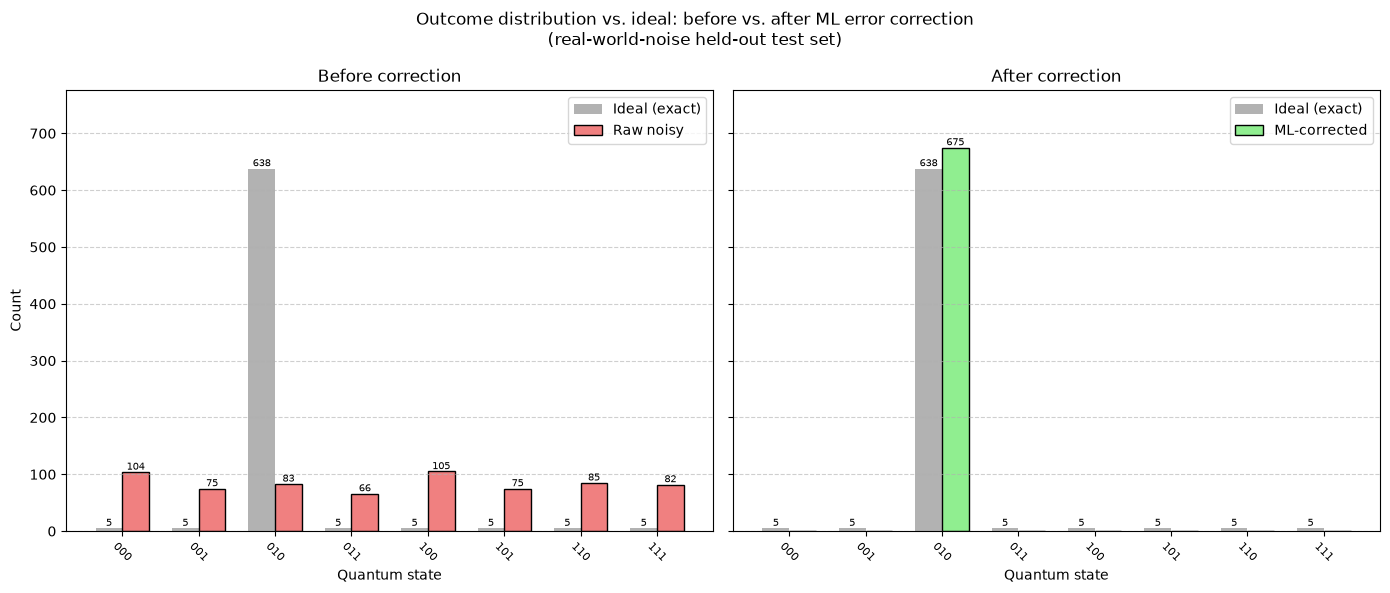


=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       11.85%
Model-corrected bitstring accuracy: 95.26%
Improvement:                        +83.41 percentage points
TVD of corrected dist. to exact ideal dist.: 0.0547

  qubit 0: raw=50.52%  corrected=96.44%
  qubit 1: raw=49.04%  corrected=96.89%
  qubit 2: raw=51.26%  corrected=97.63%


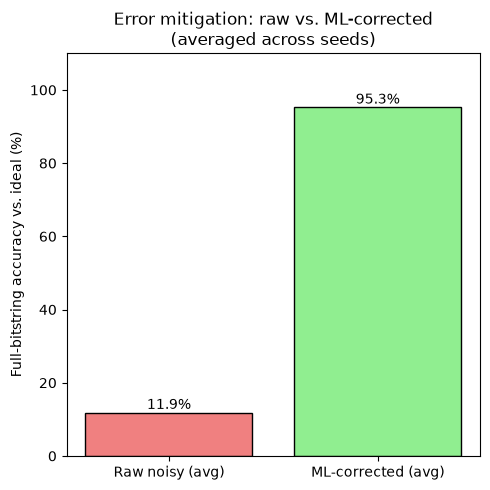

In [8]:
main(range(1),1500)